# Carbon Emission — Data Cleaning, Preprocessing & Merging
### Household: Carbon_Emission.csv | Industrial: owid-co2-data.csv
### Run each cell one by one in order

## CELL 1 — Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')
print('All libraries loaded successfully')

All libraries loaded successfully


## CELL 2 — Load Both Raw Datasets

In [3]:
df_H_raw = pd.read_csv(r'C:\Users\HP\Carbon_emission\Carbon Emission.csv')
df_I_raw = pd.read_csv(r'C:\Users\HP\Carbon_emission\owid-co2-data.csv')

print('HOUSEHOLD  — Shape:', df_H_raw.shape)
print('INDUSTRIAL — Shape:', df_I_raw.shape)
print('\nHousehold columns  :', df_H_raw.columns.tolist())
print('\nIndustrial columns :', df_I_raw.columns.tolist())

HOUSEHOLD  — Shape: (10000, 20)
INDUSTRIAL — Shape: (50411, 79)

Household columns  : ['Body Type', 'Sex', 'Diet', 'How Often Shower', 'Heating Energy Source', 'Transport', 'Vehicle Type', 'Social Activity', 'Monthly Grocery Bill', 'Frequency of Traveling by Air', 'Vehicle Monthly Distance Km', 'Waste Bag Size', 'Waste Bag Weekly Count', 'How Long TV PC Daily Hour', 'How Many New Clothes Monthly', 'How Long Internet Daily Hour', 'Energy efficiency', 'Recycling', 'Cooking_With', 'CarbonEmission']

Industrial columns : ['country', 'year', 'iso_code', 'population', 'gdp', 'cement_co2', 'cement_co2_per_capita', 'co2', 'co2_growth_abs', 'co2_growth_prct', 'co2_including_luc', 'co2_including_luc_growth_abs', 'co2_including_luc_growth_prct', 'co2_including_luc_per_capita', 'co2_including_luc_per_gdp', 'co2_including_luc_per_unit_energy', 'co2_per_capita', 'co2_per_gdp', 'co2_per_unit_energy', 'coal_co2', 'coal_co2_per_capita', 'consumption_co2', 'consumption_co2_per_capita', 'consumption_co2_

## CELL 3 — Preview Raw Data

In [4]:
print('=== HOUSEHOLD — First 5 rows ===')
display(df_H_raw.head())
print('\n=== INDUSTRIAL — First 5 rows (selected columns) ===')
display(df_I_raw[['country','year','coal_co2','oil_co2','gas_co2',
                   'cement_co2','flaring_co2','other_industry_co2','co2']].head())

=== HOUSEHOLD — First 5 rows ===


,Body Type,Sex,Diet,How Often Shower,Heating Energy Source,Transport,Vehicle Type,Social Activity,Monthly Grocery Bill,Frequency of Traveling by Air,Vehicle Monthly Distance Km,Waste Bag Size,Waste Bag Weekly Count,How Long TV PC Daily Hour,How Many New Clothes Monthly,How Long Internet Daily Hour,Energy efficiency,Recycling,Cooking_With,CarbonEmission
0,overweight,female,pescatarian,daily,coal,public,NaN,often,230,frequently,210,large,4,7,26,1,No,['Metal'],"['Stove', 'Oven']",2238
1,obese,female,vegetarian,less frequently,natural gas,walk/bicycle,NaN,often,114,rarely,9,extra large,3,9,38,5,No,['Metal'],"['Stove', 'Microwave']",1892
2,overweight,male,omnivore,more frequently,wood,private,petrol,never,138,never,2472,small,1,14,47,6,Sometimes,['Metal'],"['Oven', 'Microwave']",2595
3,overweight,male,omnivore,twice a day,wood,walk/bicycle,NaN,sometimes,157,rarely,74,medium,3,20,5,7,Sometimes,"['Paper', 'Plastic', 'Glass', 'Metal']","['Microwave', 'Grill', 'Airfryer']",1074
4,obese,female,vegetarian,daily,coal,private,diesel,often,266,very frequently,8457,large,1,3,5,6,Yes,['Paper'],['Oven'],4743



=== INDUSTRIAL — First 5 rows (selected columns) ===


,country,year,coal_co2,oil_co2,gas_co2,cement_co2,flaring_co2,other_industry_co2,co2
0,Afghanistan,1750,NaN,NaN,NaN,0.0,NaN,NaN,NaN
1,Afghanistan,1751,NaN,NaN,NaN,0.0,NaN,NaN,NaN
2,Afghanistan,1752,NaN,NaN,NaN,0.0,NaN,NaN,NaN
3,Afghanistan,1753,NaN,NaN,NaN,0.0,NaN,NaN,NaN
4,Afghanistan,1754,NaN,NaN,NaN,0.0,NaN,NaN,NaN


## CELL 4 — Household: Check Data Quality

In [5]:
print('=== HOUSEHOLD DATA QUALITY CHECK ===')
print(f'Total rows    : {len(df_H_raw)}')
print(f'Total columns : {len(df_H_raw.columns)}')
print(f'Duplicates    : {df_H_raw.duplicated().sum()}')
print(f'\nMissing values per column:')
missing = df_H_raw.isnull().sum()
print(missing[missing > 0])
print('\nData types:')
print(df_H_raw.dtypes)
print('\nCarbonEmission range:', df_H_raw['CarbonEmission'].min(), 'to', df_H_raw['CarbonEmission'].max())

=== HOUSEHOLD DATA QUALITY CHECK ===
Total rows    : 10000
Total columns : 20
Duplicates    : 0

Missing values per column:
Vehicle Type    6721
dtype: int64

Data types:
Body Type                        object
Sex                              object
Diet                             object
How Often Shower                 object
Heating Energy Source            object
Transport                        object
Vehicle Type                     object
Social Activity                  object
Monthly Grocery Bill              int64
Frequency of Traveling by Air    object
Vehicle Monthly Distance Km       int64
Waste Bag Size                   object
Waste Bag Weekly Count            int64
How Long TV PC Daily Hour         int64
How Many New Clothes Monthly      int64
How Long Internet Daily Hour      int64
Energy efficiency                object
Recycling                        object
Cooking_With                     object
CarbonEmission                    int64
dtype: object

CarbonEmission

## CELL 5 — Household: Clean Step by Step

In [6]:
df_H = df_H_raw.copy()

# ── Step 1: Standardise column names ──────────────────────────────
df_H.columns = df_H.columns.str.strip().str.lower().str.replace(' ', '_')
print('Step 1 — Columns standardised:')
print(df_H.columns.tolist())

Step 1 — Columns standardised:
['body_type', 'sex', 'diet', 'how_often_shower', 'heating_energy_source', 'transport', 'vehicle_type', 'social_activity', 'monthly_grocery_bill', 'frequency_of_traveling_by_air', 'vehicle_monthly_distance_km', 'waste_bag_size', 'waste_bag_weekly_count', 'how_long_tv_pc_daily_hour', 'how_many_new_clothes_monthly', 'how_long_internet_daily_hour', 'energy_efficiency', 'recycling', 'cooking_with', 'carbonemission']


In [7]:
# ── Step 2: Remove duplicate rows ─────────────────────────────────
before = len(df_H)
df_H = df_H.drop_duplicates()
print(f'Step 2 — Removed {before - len(df_H)} duplicates. Remaining: {len(df_H)}')

Step 2 — Removed 0 duplicates. Remaining: 10000


In [8]:
# ── Step 3: Fix Vehicle Type missing values ────────────────────────
# 6721 rows have no vehicle — they use public transport or walk
# Fill NaN with 'none' — these people have no personal vehicle
print(f'Step 3 — Vehicle Type missing before: {df_H["vehicle_type"].isnull().sum()}')
df_H['vehicle_type'] = df_H['vehicle_type'].fillna('none')
print(f'Vehicle Type missing after : {df_H["vehicle_type"].isnull().sum()}')
print('Vehicle Type values:', df_H['vehicle_type'].value_counts().to_dict())

Step 3 — Vehicle Type missing before: 6721
Vehicle Type missing after : 0
Vehicle Type values: {'none': 6721, 'lpg': 697, 'electric': 671, 'petrol': 647, 'hybrid': 642, 'diesel': 622}


In [9]:
# ── Step 4: Fix list-formatted columns ────────────────────────────
# recycling and cooking_with columns look like ["Metal"], ["Stove","Oven"]
# Convert them to clean string
import ast

def clean_list_col(val):
    try:
        items = ast.literal_eval(val)
        return '_'.join(sorted([str(i).lower().strip() for i in items]))
    except:
        return str(val).lower().strip()

df_H['recycling']    = df_H['recycling'].apply(clean_list_col)
df_H['cooking_with'] = df_H['cooking_with'].apply(clean_list_col)

print('Step 4 — List columns cleaned')
print('Recycling sample values :', df_H['recycling'].value_counts().head(5).to_dict())
print('Cooking_With sample     :', df_H['cooking_with'].value_counts().head(5).to_dict())

Step 4 — List columns cleaned
Recycling sample values : {'': 675, 'metal_paper_plastic': 648, 'glass_metal_paper': 647, 'glass_metal': 645, 'glass_metal_paper_plastic': 637}
Cooking_With sample     : {'oven_stove': 670, 'airfryer_grill_microwave_stove': 652, 'microwave_oven': 649, 'airfryer_grill_microwave_oven': 638, 'airfryer_grill_microwave_oven_stove': 637}


In [10]:
# ── Step 5: Remove outliers from numeric columns ───────────────────
numeric_cols = df_H.select_dtypes(include=['float64','int64']).columns.tolist()
before = len(df_H)
for col in numeric_cols:
    Q1 = df_H[col].quantile(0.01)
    Q3 = df_H[col].quantile(0.99)
    df_H = df_H[(df_H[col] >= Q1) & (df_H[col] <= Q3)]
print(f'Step 5 — Removed {before - len(df_H)} outlier rows. Remaining: {len(df_H)}')

Step 5 — Removed 520 outlier rows. Remaining: 9480


In [11]:
# ── Step 6: Rename target column and add type label ────────────────
df_H.rename(columns={'carbonemission': 'co2'}, inplace=True)
df_H['type'] = 'H'

print('Step 6 — Target renamed to co2, type = H added')
print('Final household shape:', df_H.shape)
print('Missing values:', df_H.isnull().sum().sum())
display(df_H.head(3))

Step 6 — Target renamed to co2, type = H added
Final household shape: (9480, 21)
Missing values: 0


,body_type,sex,diet,how_often_shower,heating_energy_source,transport,vehicle_type,social_activity,monthly_grocery_bill,frequency_of_traveling_by_air,...,waste_bag_size,waste_bag_weekly_count,how_long_tv_pc_daily_hour,how_many_new_clothes_monthly,how_long_internet_daily_hour,energy_efficiency,recycling,cooking_with,co2,type
0,overweight,female,pescatarian,daily,coal,public,none,often,230,frequently,...,large,4,7,26,1,No,metal,oven_stove,2238,H
1,obese,female,vegetarian,less frequently,natural gas,walk/bicycle,none,often,114,rarely,...,extra large,3,9,38,5,No,metal,microwave_stove,1892,H
2,overweight,male,omnivore,more frequently,wood,private,petrol,never,138,never,...,small,1,14,47,6,Sometimes,metal,microwave_oven,2595,H


## CELL 6 — Industrial: Check Data Quality

In [12]:
# Keep only the industrial feature columns relevant to your project
INDUSTRIAL_COLS = [
    'country',
    'year',
    'coal_co2',            # Coal burned for electricity
    'oil_co2',             # Oil / fuel combustion
    'gas_co2',             # Natural gas burning
    'cement_co2',          # Cement factory emissions
    'flaring_co2',         # Gas flaring in factories
    'other_industry_co2',  # Other industrial processes
    'co2'                  # TARGET — total CO2 (million tonnes)
]

df_I_check = df_I_raw[INDUSTRIAL_COLS].copy()
print('=== INDUSTRIAL DATA QUALITY CHECK ===')
print(f'Total rows    : {len(df_I_check)}')
print(f'Duplicates    : {df_I_check.duplicated().sum()}')
print(f'\nMissing values:')
print(df_I_check.isnull().sum())
print(f'\nYear range: {df_I_raw["year"].min()} to {df_I_raw["year"].max()}')

=== INDUSTRIAL DATA QUALITY CHECK ===
Total rows    : 50411
Duplicates    : 0

Missing values:
country                   0
year                      0
coal_co2              28486
oil_co2               24952
gas_co2               32264
cement_co2            21238
flaring_co2           34237
other_industry_co2    47157
co2                   21027
dtype: int64

Year range: 1750 to 2024


## CELL 7 — Industrial: Clean Step by Step

In [13]:
df_I = df_I_raw[INDUSTRIAL_COLS].copy()

# ── Step 1: Filter to year 2000 onwards (relevant modern data) ─────
df_I = df_I[df_I['year'] >= 2000]
print(f'Step 1 — After year >= 2000 filter: {len(df_I)} rows')

Step 1 — After year >= 2000 filter: 6350 rows


In [14]:
# ── Step 2: Remove rows where CO2 target is missing or zero ────────
before = len(df_I)
df_I = df_I.dropna(subset=['co2'])
df_I = df_I[df_I['co2'] > 0]
print(f'Step 2 — Removed {before - len(df_I)} bad CO2 rows. Remaining: {len(df_I)}')

Step 2 — Removed 267 bad CO2 rows. Remaining: 6083


In [15]:
# ── Step 3: Fill missing feature values with 0 ─────────────────────
fill_cols = ['coal_co2','oil_co2','gas_co2','cement_co2',
             'flaring_co2','other_industry_co2']
df_I[fill_cols] = df_I[fill_cols].fillna(0)
print(f'Step 3 — Missing feature values filled with 0')
print('Missing values remaining:', df_I.isnull().sum().sum())

Step 3 — Missing feature values filled with 0
Missing values remaining: 0


In [16]:
# ── Step 4: Remove duplicates ──────────────────────────────────────
before = len(df_I)
df_I = df_I.drop_duplicates()
print(f'Step 4 — Removed {before - len(df_I)} duplicates. Remaining: {len(df_I)}')

Step 4 — Removed 0 duplicates. Remaining: 6083


In [17]:
# ── Step 5: Convert CO2 from million tonnes to kg ──────────────────
# Household CO2 is in kg (306 to 8377 kg)
# Industrial CO2 is in million tonnes — convert to kg so both match
# 1 million tonne = 1,000,000,000 kg
df_I['co2'] = df_I['co2'] * 1_000_000_000
print(f'Step 5 — CO2 converted to kg')
print(f'Industrial CO2 range: {df_I["co2"].min():.0f} to {df_I["co2"].max():.0f} kg')

Step 5 — CO2 converted to kg
Industrial CO2 range: 4000000 to 38598578000000 kg


In [18]:
# ── Step 6: Encode country column ─────────────────────────────────
le_country = LabelEncoder()
df_I['country'] = le_country.fit_transform(df_I['country'].astype(str))
print(f'Step 6 — Country encoded. Unique countries: {len(le_country.classes_)}')

Step 6 — Country encoded. Unique countries: 244


In [19]:
# ── Step 7: Add type label ─────────────────────────────────────────
df_I['type'] = 'I'
print('Step 7 — type = I added')
print('Final industrial shape:', df_I.shape)
print('Missing values:', df_I.isnull().sum().sum())
display(df_I.head(3))

Step 7 — type = I added
Final industrial shape: (6083, 10)
Missing values: 0


,country,year,coal_co2,oil_co2,gas_co2,cement_co2,flaring_co2,other_industry_co2,co2,type
250,0,2000,0.004,0.788,0.224,0.010,0.022,0.0,1.047000e+09,I
251,0,2001,0.070,0.762,0.209,0.007,0.022,0.0,1.069000e+09,I
252,0,2002,0.055,0.729,0.546,0.011,0.000,0.0,1.341000e+09,I


## CELL 8 — Merge Both Datasets

In [20]:
print('=== BEFORE MERGE ===')
print(f'Household  rows : {len(df_H)} | columns : {df_H.columns.tolist()}')
print(f'Industrial rows : {len(df_I)} | columns : {df_I.columns.tolist()}')

# Merge — columns not present in one dataset fill with NaN → then 0
df = pd.concat([df_H, df_I], ignore_index=True)
df = df.fillna(0)

print('\n=== AFTER MERGE ===')
print('Shape:', df.shape)
print('\nType distribution — MUST show both H and I:')
print(df['type'].value_counts())
display(df.sample(6))

=== BEFORE MERGE ===
Household  rows : 9480 | columns : ['body_type', 'sex', 'diet', 'how_often_shower', 'heating_energy_source', 'transport', 'vehicle_type', 'social_activity', 'monthly_grocery_bill', 'frequency_of_traveling_by_air', 'vehicle_monthly_distance_km', 'waste_bag_size', 'waste_bag_weekly_count', 'how_long_tv_pc_daily_hour', 'how_many_new_clothes_monthly', 'how_long_internet_daily_hour', 'energy_efficiency', 'recycling', 'cooking_with', 'co2', 'type']
Industrial rows : 6083 | columns : ['country', 'year', 'coal_co2', 'oil_co2', 'gas_co2', 'cement_co2', 'flaring_co2', 'other_industry_co2', 'co2', 'type']

=== AFTER MERGE ===
Shape: (15563, 29)

Type distribution — MUST show both H and I:
type
H    9480
I    6083
Name: count, dtype: int64


,body_type,sex,diet,how_often_shower,heating_energy_source,transport,vehicle_type,social_activity,monthly_grocery_bill,frequency_of_traveling_by_air,...,co2,type,country,year,coal_co2,oil_co2,gas_co2,cement_co2,flaring_co2,other_industry_co2
6663,underweight,female,pescatarian,twice a day,wood,public,none,never,195.0,very frequently,...,1666.0,H,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0
5195,underweight,male,vegetarian,less frequently,natural gas,walk/bicycle,none,never,128.0,frequently,...,1786.0,H,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0
8108,underweight,male,pescatarian,more frequently,coal,public,none,sometimes,227.0,never,...,1625.0,H,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0
1460,underweight,male,pescatarian,daily,electricity,walk/bicycle,none,often,272.0,very frequently,...,2431.0,H,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0
2869,normal,male,vegan,twice a day,coal,walk/bicycle,none,sometimes,118.0,never,...,1059.0,H,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0
14185,0,0,0,0,0,0,0,0,0.0,0,...,518000000.0,I,188.0,2022.0,0.0,0.518,0.0,0.0,0.0,0.0


## CELL 9 — Encode All Text Columns to Numbers

In [21]:
text_cols = df.select_dtypes(include=['object']).columns.tolist()
print('Text columns to encode:', text_cols)

le = LabelEncoder()
label_maps = {}

for col in text_cols:
    df[col] = df[col].astype(str)
    df[col] = le.fit_transform(df[col])
    label_maps[col] = dict(zip(le.classes_, map(int, le.transform(le.classes_))))

print('\nEncoding complete.')
print('type mapping:', label_maps['type'])

Text columns to encode: ['body_type', 'sex', 'diet', 'how_often_shower', 'heating_energy_source', 'transport', 'vehicle_type', 'social_activity', 'frequency_of_traveling_by_air', 'waste_bag_size', 'energy_efficiency', 'recycling', 'cooking_with', 'type']

Encoding complete.
type mapping: {'H': 0, 'I': 1}


## CELL 10 — Final Quality Check

In [22]:
print('=== FINAL MERGED DATASET ===')
print(f'Total rows     : {len(df)}')
print(f'Total columns  : {len(df.columns)}')
print(f'Missing values : {df.isnull().sum().sum()}')
print(f'All numeric    : {all(df.dtypes != object)}')
print(f'Columns        : {df.columns.tolist()}')

h_val = label_maps['type']['H']
i_val = label_maps['type']['I']

print(f'\nHousehold rows : {(df["type"] == h_val).sum()}')
print(f'Industrial rows: {(df["type"] == i_val).sum()}')

print(f'\nHousehold CO2  — min: {df[df["type"]==h_val]["co2"].min():.0f}  max: {df[df["type"]==h_val]["co2"].max():.0f} kg')
print(f'Industrial CO2 — min: {df[df["type"]==i_val]["co2"].min():.0f}  max: {df[df["type"]==i_val]["co2"].max():.0f} kg')

=== FINAL MERGED DATASET ===
Total rows     : 15563
Total columns  : 29
Missing values : 0
All numeric    : True
Columns        : ['body_type', 'sex', 'diet', 'how_often_shower', 'heating_energy_source', 'transport', 'vehicle_type', 'social_activity', 'monthly_grocery_bill', 'frequency_of_traveling_by_air', 'vehicle_monthly_distance_km', 'waste_bag_size', 'waste_bag_weekly_count', 'how_long_tv_pc_daily_hour', 'how_many_new_clothes_monthly', 'how_long_internet_daily_hour', 'energy_efficiency', 'recycling', 'cooking_with', 'co2', 'type', 'country', 'year', 'coal_co2', 'oil_co2', 'gas_co2', 'cement_co2', 'flaring_co2', 'other_industry_co2']

Household rows : 9480
Industrial rows: 6083

Household CO2  — min: 705  max: 5366 kg
Industrial CO2 — min: 4000000  max: 38598578000000 kg


## CELL 11 — Visualise Merged Data

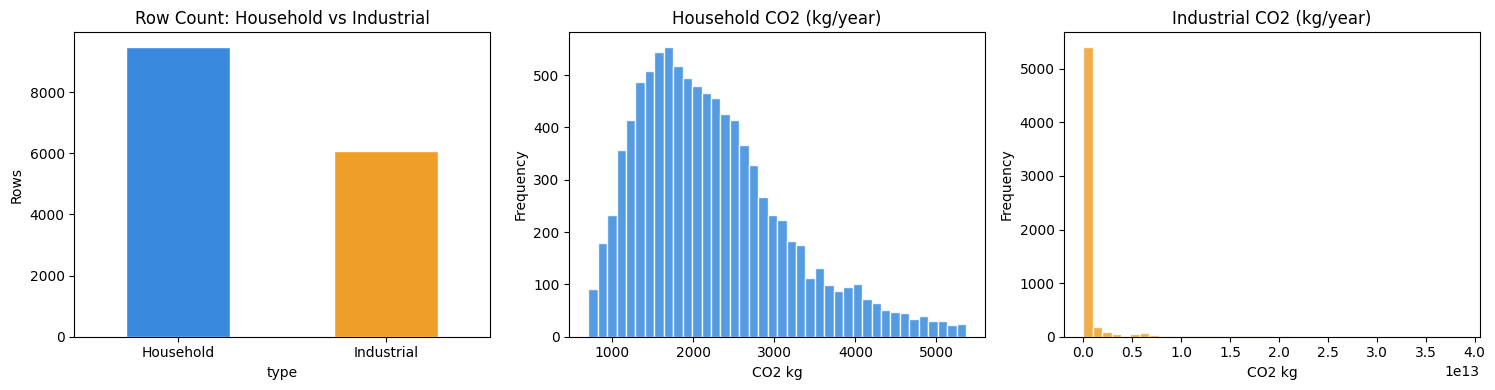

Chart saved


In [23]:
h_val = label_maps['type']['H']
i_val = label_maps['type']['I']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Chart 1: Row count H vs I
df['type'].map({h_val:'Household', i_val:'Industrial'}).value_counts().plot(
    kind='bar', ax=axes[0], color=['#378ADD','#EF9F27'], edgecolor='white'
)
axes[0].set_title('Row Count: Household vs Industrial')
axes[0].set_ylabel('Rows')
axes[0].tick_params(axis='x', rotation=0)

# Chart 2: Household CO2 distribution
df[df['type']==h_val]['co2'].plot(
    kind='hist', bins=40, ax=axes[1], color='#378ADD', alpha=0.85, edgecolor='white'
)
axes[1].set_title('Household CO2 (kg/year)')
axes[1].set_xlabel('CO2 kg')

# Chart 3: Industrial CO2 distribution
df[df['type']==i_val]['co2'].plot(
    kind='hist', bins=40, ax=axes[2], color='#EF9F27', alpha=0.85, edgecolor='white'
)
axes[2].set_title('Industrial CO2 (kg/year)')
axes[2].set_xlabel('CO2 kg')

plt.tight_layout()
plt.savefig(r'C:\Users\HP\Carbon_emission\merged_distribution.png', dpi=120)
plt.show()
print('Chart saved')

## CELL 12 — Save Final Merged File

In [24]:
import joblib

save_path = r'C:\Users\HP\Carbon_emission\merged_carbon_final.csv'
df.to_csv(save_path, index=False)

# Also save label maps for use in training notebook
joblib.dump(label_maps, r'C:\Users\HP\Carbon_emission\label_maps.pkl')

print('=' * 55)
print('  DATA CLEANING AND MERGE COMPLETE')
print('=' * 55)
print(f'  File saved : merged_carbon_final.csv')
print(f'  Total rows : {len(df)}')
print(f'  Household  : {(df["type"]==label_maps["type"]["H"]).sum()} rows')
print(f'  Industrial : {(df["type"]==label_maps["type"]["I"]).sum()} rows')
print(f'  Columns    : {df.columns.tolist()}')
print('=' * 55)
print('  Next step: open training notebook and load merged_carbon_final.csv')

  DATA CLEANING AND MERGE COMPLETE
  File saved : merged_carbon_final.csv
  Total rows : 15563
  Household  : 9480 rows
  Industrial : 6083 rows
  Columns    : ['body_type', 'sex', 'diet', 'how_often_shower', 'heating_energy_source', 'transport', 'vehicle_type', 'social_activity', 'monthly_grocery_bill', 'frequency_of_traveling_by_air', 'vehicle_monthly_distance_km', 'waste_bag_size', 'waste_bag_weekly_count', 'how_long_tv_pc_daily_hour', 'how_many_new_clothes_monthly', 'how_long_internet_daily_hour', 'energy_efficiency', 'recycling', 'cooking_with', 'co2', 'type', 'country', 'year', 'coal_co2', 'oil_co2', 'gas_co2', 'cement_co2', 'flaring_co2', 'other_industry_co2']
  Next step: open training notebook and load merged_carbon_final.csv


In [1]:

import pandas as pd

df = pd.read_csv(r'C:\Users\HP\Carbon_emission\merged_carbon_final.csv')

# Convert industrial feature columns from million tonnes to kg
# Only for industrial rows (type == 1)
scale_cols = ['coal_co2', 'oil_co2', 'gas_co2',
              'cement_co2', 'flaring_co2', 'other_industry_co2']

df.loc[df['type'] == 1, scale_cols] = \
  df.loc[df['type'] == 1, scale_cols] * 1_000_000_000

# Verify fix
h = df[df['type']==0]['co2']
i = df[df['type']==1]['co2']
print(f'Household CO2 — min: {h.min():.0f} max: {h.max():.0f}')
print(f'Industrial CO2 — min: {i.min():.2e} max: {i.max():.2e}')

# Save fixed file
df.to_csv(r'C:\Users\HP\Carbon_emission\merged_carbon_final.csv', index=False)
print('Fixed and saved!')

Household CO2 — min: 705 max: 5366
Industrial CO2 — min: 4.00e+06 max: 3.86e+13
Fixed and saved!
